# Pythonprogrammering och AI strategi, möjligheter och utmaningar

## Exploratory Data Analysis (EDA) - Housing Dataset
I denna analys undersöker jag bostadsdata för att identifiera mönster som påverkar prissättningen. Jag kommer, eller i alla fall försöka titta på korrelationer, hantera saknade värden och visualisera priser. Jag har använd Pycharm som IDE och Jupyter Notebook för att skriva och köra koden.

Jag går igenom följande steg:
1. Inspektera data och eventuell rengöring.
2. Beskriva statistik.
3. Visualisera fördelningar och samband.
4. Slutsatser - Självutvärdering.

==========================================================================================
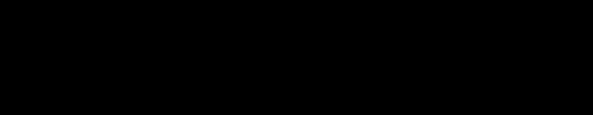
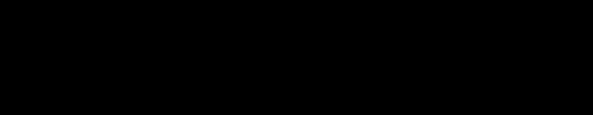

## 1. Datainspektion och rengöring
Innan analysen kollar jag efter saknade värden och efter ev felaktiga/konstiga data.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ladda datan
try:
    df = pd.read_csv("data/housing.csv") # Lagt datasetet i datamappen
    print("Datasetet laddades")
except FileNotFoundError:
    print("Kunde inte hitta filen. Kontrollera att den ligger i mappen 'data'.")
    # Stoppa här om filen saknas. Kan bli konstiga följdfel
    raise SystemExit

# Ändrar rubrikerna till svenska - kanske var dumt nu när jag tänker efter. Man bör nog inte ha mellanslag
sv_namn = {
    "longitude":          "Longitud",
    "latitude":           "Latitud",
    "housing_median_age": "Husets ålder median",
    "total_rooms":        "Antal rum totalt",
    "total_bedrooms":     "Antal sovrum totalt",
    "population":         "Befolkning",
    "households":         "Hushåll",
    "median_income":      "Medianinkomst",
    "median_house_value": "Huspris median",
    "ocean_proximity":    "Närhet till havet"
}

df.rename(columns=sv_namn, inplace=True)

# Kontroll/hantering av saknad data
print("--- KONTROLL AV SAKNADE VÄRDEN ---")
print(df.isnull().sum())

# Jag fyller i de 207 saknade värdena med medianen för att inte förlora data.
sovrum_median = df["Antal sovrum totalt"].median()
df["Antal sovrum totalt"] = df["Antal sovrum totalt"].fillna(sovrum_median)

print("\n--- KONTROLL EFTER ÅTGÄRD ---")
print("Saknade värden i antal sovrum totalt:", df["Antal sovrum totalt"].isnull().sum())

print("\n--- KONTROLL AV DATAFRAME ---")
# Kolla att de blivit svensk översättning
print(f"Antal kolumner: {len(df.columns)}")
print("Nya kolumnnamn:", list(df.columns))

print("\n--- DATATYPER OCH TOMMA VÄRDEN ---")
# Kolla nollvärden
df.info()

print("\n--- FÖRSTA FEM RADERNA I DATASETET ---")
print(df.head())

# Kolla om vi har några noll-värden kvar efter rengöring
print("\nSaknade värden per kolumn:")
print(df.isnull().sum())

# Jag fyllde i de saknade värdena i "antal_sovrum_totalt" med medianen för att inte förlora data.

# Räkna ut medianen för sovrum
sovrum_median = df["Antal sovrum totalt"].median()
# Fyll de tomma cellerna med medianvärdet
df["Antal sovrum totalt"] = df["Antal sovrum totalt"].fillna(sovrum_median)
# Kontrollera att det blev 0 nu
print("Saknade värden efter rättning:", df["Antal sovrum totalt"].isnull().sum())

Datasetet laddades
--- KONTROLL AV SAKNADE VÄRDEN ---
Longitud                 0
Latitud                  0
Husets ålder median      0
Antal rum totalt         0
Antal sovrum totalt    207
Befolkning               0
Hushåll                  0
Medianinkomst            0
Huspris median           0
Närhet till havet        0
dtype: int64

--- KONTROLL EFTER ÅTGÄRD ---
Saknade värden i antal sovrum totalt: 0

--- KONTROLL AV DATAFRAME ---
Antal kolumner: 10
Nya kolumnnamn: ['Longitud', 'Latitud', 'Husets ålder median', 'Antal rum totalt', 'Antal sovrum totalt', 'Befolkning', 'Hushåll', 'Medianinkomst', 'Huspris median', 'Närhet till havet']

--- DATATYPER OCH TOMMA VÄRDEN ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Longitud             20640 non-null  float64
 1   Latitud              20640 non-null  float64
 2   Husets ålder med

## 2. Statistisk sammanfattning
Jag tittar på måtten för att få en överblick.

In [20]:

print("--- STATISTISK ÖVERSIKT ---")
# Rundar av till två decimaler för att det ska bli lättare att läsa
print(df.describe().round(2))

--- STATISTISK ÖVERSIKT ---
       Longitud   Latitud  Husets ålder median  Antal rum totalt  \
count  20640.00  20640.00             20640.00          20640.00   
mean    -119.57     35.63                28.64           2635.76   
std        2.00      2.14                12.59           2181.62   
min     -124.35     32.54                 1.00              2.00   
25%     -121.80     33.93                18.00           1447.75   
50%     -118.49     34.26                29.00           2127.00   
75%     -118.01     37.71                37.00           3148.00   
max     -114.31     41.95                52.00          39320.00   

       Antal sovrum totalt  Befolkning   Hushåll  Medianinkomst  \
count             20640.00    20640.00  20640.00       20640.00   
mean                536.84     1425.48    499.54           3.87   
std                 419.39     1132.46    382.33           1.90   
min                   1.00        3.00      1.00           0.50   
25%                 297.

## 3. Visualiseringar
### Prisfördelning
Jag börjar med att titta på hur priserna är fördelade. Är de flesta husen billiga eller finns det många lyxvillor?

--- KORRELATION MED HUSPRIS MEDIAN ---
Huspris median         1.000000
Medianinkomst          0.688075
Antal rum totalt       0.134153
Husets ålder median    0.105623
Hushåll                0.065843
Antal sovrum totalt    0.049457
Befolkning            -0.024650
Longitud              -0.045967
Latitud               -0.144160
Name: Huspris median, dtype: float64


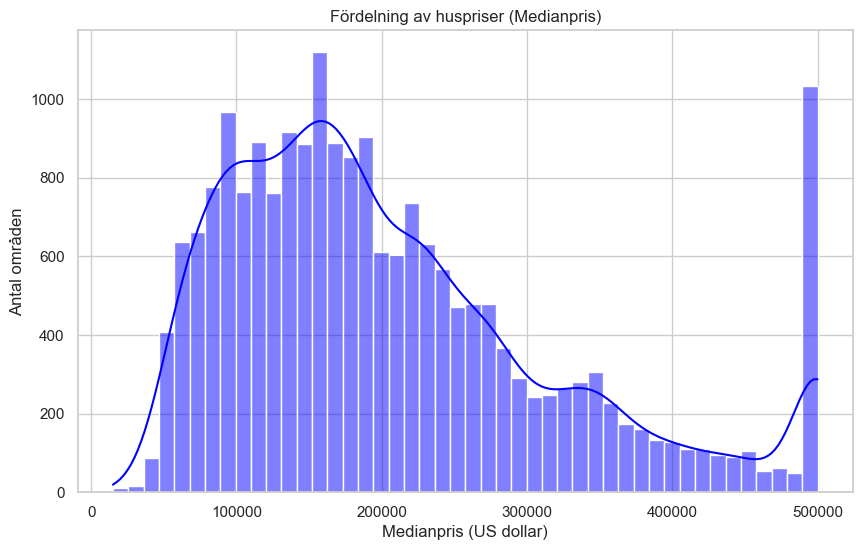

In [21]:
# --- KORRELATION ---
print("--- KORRELATION MED HUSPRIS MEDIAN ---")
korrelationer = df.corr(numeric_only=True)
print(korrelationer["Huspris median"].sort_values(ascending=False))

# --- VISUALISERING ---
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df["Huspris median"], kde=True, color="blue")

plt.title("Fördelning av huspriser (Medianpris)")
plt.xlabel("Medianpris (US dollar)")
plt.ylabel("Antal områden")
plt.show()


### Samband mellan "Inkomst" och "Huspris"
Här undersöks om inkomst alltid innebär ett högre pris. Jag använder ett "scatter-plot" för att se trenden. Här ser vi att husen nära kusten är betydligt dyrare (röda) än de i inlandet (blå), vilket bekräftar att läget är avgörande.

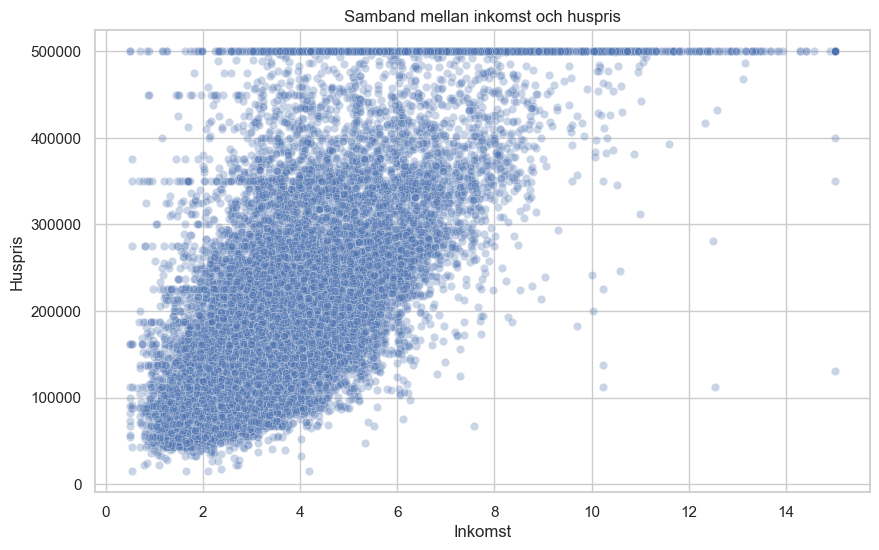

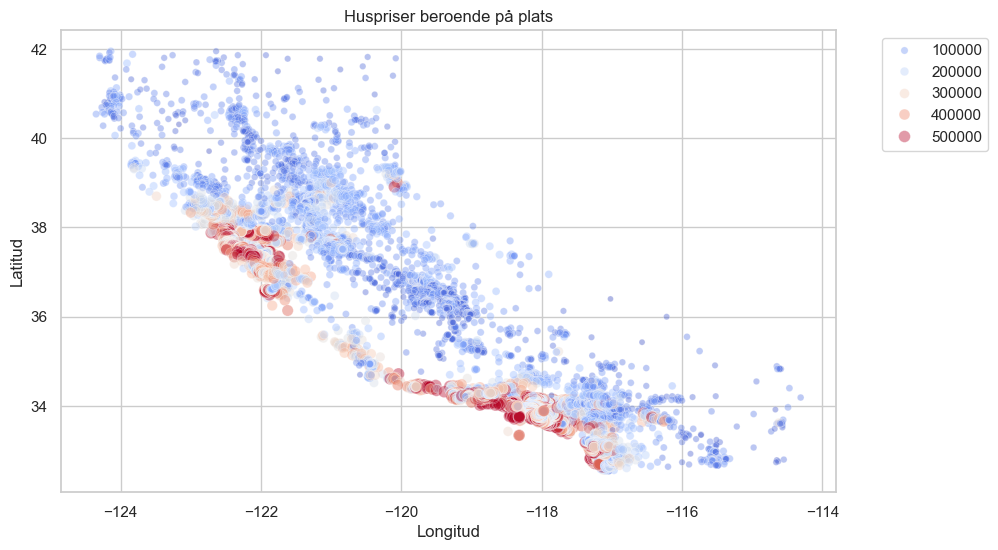

In [22]:
# Skapa figuren (storleken)
plt.figure(figsize=(10, 6))

# Rita diagrammet på figuren
sns.scatterplot(data=df, x="Medianinkomst", y="Huspris median", alpha=0.3) # Mörkare blå färg där det är mycket prickar


# Lägg på text och etiketter
plt.title("Samband mellan inkomst och huspris")
plt.xlabel("Inkomst")
plt.ylabel("Huspris")

# Visa resultatet
plt.show()

# Geografiskt graf
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Longitud", y="Latitud", size="Huspris median",
                hue="Huspris median", palette="coolwarm", alpha=0.4)

plt.title("Huspriser beroende på plats")
# Flyttar legenden så den inte täcker kartan
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Korrelationsmatris
Vilka variabler har starkast koppling till varandra? En "heatmap" (Coolwarm) visar svaret.

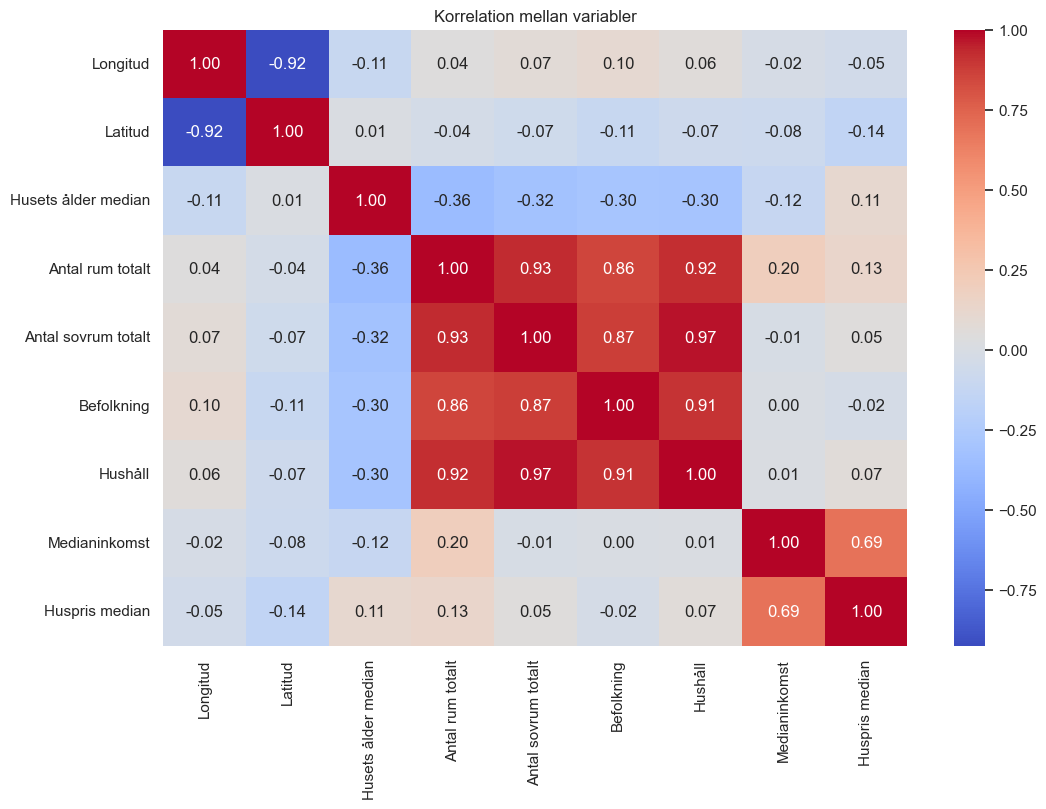

In [23]:
plt.figure(figsize=(12, 8))
# Vi korrelerar endast numeriska värden
correlation_matrix = df.select_dtypes(include=["number"]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelation mellan variabler")
plt.show()

## 4. Slutsatser - Självutvärdering:
### 1. Utmaningar och lärdomar

Den största utmaningen var i början att förstå hur man hanterar bibliotek som Pandas och hur man navigerar i Jupyter Notebook. Tog ett tag innan jag fick kläm på hur Jupyter fungerar (Code/Markdown). Jag hanterade det genom att testa mig fram. Läste dokumentationen och delade upp koden i mindre bitar. En viktig lärdom är vikten av att städa datan (som att fixa de 207 saknade sovrummen) innan man börjar analysera annars kan resultatet bli felaktigt. En stor lärdom är hur mycket tid som faktiskt går åt till förberedelser innan man kan göra själva analysen. Jag är glad att jag började i tid. Jag har använt PyCharm med inbyggd stöd för Jupyter Notebook.

### 2. Vilket betyg anser du att du ska ha?

Jag tycker att arbetet håller en bra nivå. Absolut G men ska det vara G eller VG? Lämnar ödmjukt den frågan till dig Terese. Jag tycker jag har genomfört en komplett kedja: import, rengöring, analys och visualisering. Jag har också tolkat resultaten istället för att bara presentera siffror.
* Översatt och strukturerat om datasetet för bättre läsbarhet.
* Hanterat saknade värden med logiska metoder (median-imput).
* Genomfört en statistisk analys av korrelationer.
* Skapat tydliga visualiseringar som histogram och scatterplots för att dra slutsatser.


### 3. Något du vill lyfta fram till Terese?

Jag tyckte det var särskilt intressant att se hur tydligt sambandet mellan inkomst och pris faktiskt var i praktiken. Det gav en bättre förståelse för hur man kan använda Python för att bekräfta teorier med hjälp av riktig data. Jag ser fram emot att lära mig mer om hur man kan bygga modeller (Machine Learning) baserat på denna typ av analys i framtiden. Jag uppskattade att arbeta med ett verkligt dataset. Det gjorde det tydligt varför programmering är ett så kraftfullt verktyg för att förstå stora mängder information som annars hade varit omöjlig att överblicka i t.ex. Excel.


### Slutkläm...

* Vilken faktor var viktigast? Medianinkomst.
* Fanns det något konstigt i datan? Pris-taket vid 500 000 dollar.
* Vad betyder detta för någon som vill köpa ett hus i Kalifornien? Vill du bo vid kusten bör du ha mer än 500 000 dollar.
